# Treatment Rules Based on Fracture Detection

Now that the model can detect fractures and metal hardware, I will add a rule-based system to suggest treatment recommendations based on the detected conditions. This provides clinical decision support alongside the diagnosis and explanation.

In [1]:
import torch
import torch.nn as nn
import torchvision.models as models
import random
import os
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image
import numpy as np
import torchvision.transforms as transforms

# Set device
device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')

# --- LOAD RESNET CLASSIFIER ---
resnet_model = models.resnet50(weights=None)
resnet_model.fc = nn.Linear(resnet_model.fc.in_features, 3)
resnet_model.load_state_dict(torch.load('../models/checkpoints/baseline_resnet50.pth', map_location='cpu'))
resnet_model = resnet_model.to(device)
resnet_model.eval()
print("✅ ResNet model loaded!")

# --- DEFINE TREATMENT RULES ---
def get_treatment_recommendation(detected_classes):
    """Return treatment recommendation based on detected classes."""
    
    recommendations = {
        "Fractura": {
            "suggestion": "Immobilize wrist with splint or cast. Follow up with orthopedic specialist within 1 week.",
            "severity": "Moderate",
            "follow_up": "X-ray follow-up in 2 weeks"
        },
        "Metal": {
            "suggestion": "Monitor surgical hardware. Routine follow-up with orthopedic surgeon.",
            "severity": "Mild",
            "follow_up": "Annual X-ray to check hardware position"
        },
        "Fractura_Metal": {
            "suggestion": "Surgical consultation required. Possible internal fixation or hardware revision.",
            "severity": "Severe",
            "follow_up": "Immediate orthopedic referral"
        },
        "None": {
            "suggestion": "No fracture detected. Rest and monitor symptoms.",
            "severity": "None",
            "follow_up": "Seek medical attention if pain continues"
        }
    }
    
    if "Fractura" in detected_classes and "Metal" in detected_classes:
        return recommendations["Fractura_Metal"]
    elif "Fractura" in detected_classes:
        return recommendations["Fractura"]
    elif "Metal" in detected_classes:
        return recommendations["Metal"]
    else:
        return recommendations["None"]

print("✅ Treatment rules defined!")

✅ ResNet model loaded!
✅ Treatment rules defined!


# Checking if Ollama is installed and running

Before using Ollama for treatment suggestions, I need to verify that Ollama is installed and running on the system. I will use a Python subprocess to check the Ollama version.

In [2]:
import subprocess
import sys

try:
    result = subprocess.run(['ollama', '--version'], capture_output=True, text=True)
    if result.returncode == 0:
        print(f"✅ Ollama installed: {result.stdout.strip()}")
    else:
        print("❌ Ollama not found. Please install Ollama first.")
        print("Run in terminal: curl -fsSL https://ollama.com/install.sh | sh")
except FileNotFoundError:
    print("❌ Ollama not found. Please install Ollama first.")
    print("Run in terminal: curl -fsSL https://ollama.com/install.sh | sh")

✅ Ollama installed: ollama version is 0.32.0


# Pulling a Lightweight LLM Model for Treatment Suggestions

I will now download the LLaMA 3.2 3B model using Ollama. This model is lightweight (runs well on M4) and capable of generating reasonable medical treatment suggestions based on our ResNet predictions.

In [3]:
import subprocess
import sys

print("📥 Pulling LLaMA 3.2 3B model...")
print("This may take a few minutes depending on your internet speed.")

try:
    result = subprocess.run(['ollama', 'pull', 'llama3.2:3b'], capture_output=True, text=True)
    if result.returncode == 0:
        print("✅ Model pulled successfully!")
        print(result.stdout[-200:])  # Show last 200 characters
    else:
        print(f"❌ Error pulling model: {result.stderr}")
except Exception as e:
    print(f"❌ Error: {e}")

📥 Pulling LLaMA 3.2 3B model...
This may take a few minutes depending on your internet speed.
✅ Model pulled successfully!



# Testing the LLaMA Model with a Simple Medical Query

Before integrating with ResNet, I will test the model with a basic question to confirm it's working correctly and generating reasonable responses.

In [6]:
import ollama

response = ollama.chat(
    model='llama3.2:3b',
    messages=[{'role': 'user', 'content': 'What is the first step in treating a wrist fracture?'}]
)

print("🤖 Test Response:")
print("-" * 60)
print(response['message']['content'])
print("-" * 60)
print("✅ Model is working!")

🤖 Test Response:
------------------------------------------------------------
The first step in treating a wrist fracture typically involves immobilization and reducing pain. Here's a general outline of the initial steps:

1. **Stop activity**: The person with a wrist fracture should stop any activities that may have caused or exacerbated the injury.
2. **Assess the injury**: A medical professional will evaluate the fracture, assess its severity, and determine the best course of treatment.
3. **Immobilization**: The wrist is usually immobilized using a splint, sling, or cast to reduce movement and promote healing. This helps to:
	* Reduce pain
	* Prevent further injury
	* Allow the bone to start the healing process
4. **Pain management**: Pain relief medication may be prescribed to manage discomfort and inflammation.
5. **Imaging studies**: X-rays are usually taken to confirm the diagnosis, assess the fracture's severity, and rule out other potential injuries.

It's essential to seek m

# Complete Integration: Detection + Explanation + Treatment

Now I will combine all components into a single workflow:
1. ResNet detects Fractura, Metal, Texto
2. Conditional caption generated based on detection
3. Grad-CAM heatmap highlights the detected region
4. LLaMA generates a treatment recommendation
5. All results displayed together

✅ ResNet model loaded!
📸 Image: 2762_0427660757_01_WRI-L2_M011_png.rf.5761a71a5cab49235dd8d1590dcdebf7.jpg
📊 ResNet Probabilities:
  Fractura: 0.9912
  Metal: 0.0001
  Texto: 0.9999
✅ Detected classes: ['Fractura', 'Texto']
📝 Generated Caption: Fracture detected

🤖 Generating treatment description...
✅ Treatment description generated!

💊 Clinical Management Description:
------------------------------------------------------------
In orthopedics, a fracture is a common injury that requires prompt attention and proper management to ensure optimal healing and prevent long-term complications. Here's an overview of the typical clinical management and follow-up protocol for a patient with wrist X-ray findings indicating a fracture:

**Standard Treatment Approach:**

The primary goal of treatment is to reduce pain, restore function, and promote healing. The standard treatment approach may include:

1. **Immobilization**: A wrist splint or cast is often used to immobilize the affected area, al

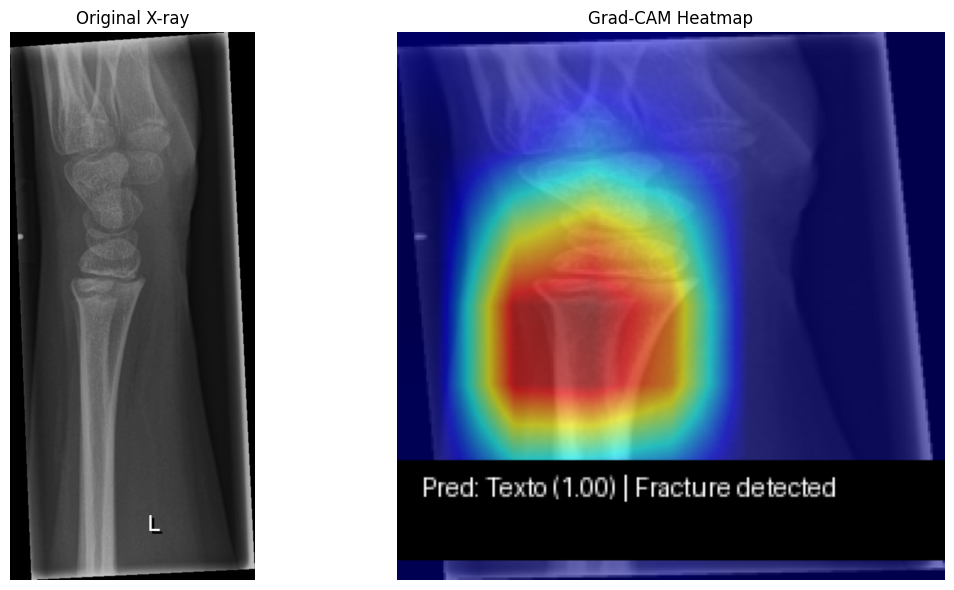


✅ Complete!


In [10]:
import ollama
import torch
import random
import os
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image, ImageDraw
import numpy as np
import torchvision.transforms as transforms
import torch.nn as nn
import torchvision.models as models
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image

# Set device
device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')

# --- LOAD RESNET CLASSIFIER ---
resnet_model = models.resnet50(weights=None)
resnet_model.fc = nn.Linear(resnet_model.fc.in_features, 3)
resnet_model.load_state_dict(torch.load('../models/checkpoints/baseline_resnet50.pth', map_location='cpu'))
resnet_model = resnet_model.to(device)
resnet_model.eval()
print("✅ ResNet model loaded!")

# --- LOAD A RANDOM TEST IMAGE ---
test_img_dir = Path('../data/raw/test')
test_images = [f for f in os.listdir(test_img_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
sample_img_path = test_img_dir / random.choice(test_images)
image = Image.open(sample_img_path).convert('RGB')

# --- STEP 1: GET RESNET PREDICTIONS ---
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                         std=[0.229, 0.224, 0.225])
])

input_tensor = transform(image).unsqueeze(0).to(device)

with torch.no_grad():
    outputs = resnet_model(input_tensor)
    probs = torch.sigmoid(outputs).cpu().numpy()[0]

class_names = ['Fractura', 'Metal', 'Texto']
threshold = 0.5

# Determine which classes are present
detected_classes = []
for i, name in enumerate(class_names):
    if probs[i] >= threshold:
        detected_classes.append(name)

print(f"📸 Image: {sample_img_path.name}")
print(f"📊 ResNet Probabilities:")
for i, name in enumerate(class_names):
    print(f"  {name}: {probs[i]:.4f}")
print(f"✅ Detected classes: {detected_classes if detected_classes else 'None'}")

# --- STEP 2: GENERATE CONDITIONAL CAPTION ---
if len(detected_classes) == 0:
    caption = "Normal: No fracture, no metal"
elif "Fractura" in detected_classes and "Metal" in detected_classes:
    caption = "Fracture + Metal detected"
elif "Fractura" in detected_classes:
    caption = "Fracture detected"
elif "Metal" in detected_classes:
    caption = "Metal hardware detected"
elif "Texto" in detected_classes:
    caption = "Text annotations present"
else:
    caption = "Abnormalities detected"

pred_idx = np.argmax(probs)
pred_name = class_names[pred_idx]
pred_conf = probs[pred_idx]

print(f"📝 Generated Caption: {caption}")

# --- STEP 3: GENERATE TREATMENT SUGGESTION (SAFE PROMPT) ---
if len(detected_classes) == 0:
    diagnosis = "Normal wrist X-ray, no abnormalities detected"
else:
    diagnosis = f"Wrist X-ray findings: {', '.join(detected_classes)}"

# Build a prompt that frames it as educational/clinical description
prompt = f"""As a medical student studying orthopedics, describe the typical clinical management and follow-up protocol for a patient with the following wrist X-ray findings: {diagnosis}.

Please describe:
1. The standard treatment approach
2. Typical follow-up timeline
3. When a specialist referral would be considered

Provide this as educational clinical knowledge, not specific medical advice."""

print("\n🤖 Generating treatment description...")

try:
    response = ollama.chat(
        model='llama3.2:3b',
        messages=[{'role': 'user', 'content': prompt}]
    )
    treatment = response['message']['content']
    print("✅ Treatment description generated!")
except Exception as e:
    treatment = f"⚠️ Error generating treatment: {e}"
    print(f"❌ {treatment}")

print("\n💊 Clinical Management Description:")
print("-" * 60)
print(treatment)
print("-" * 60)

# --- STEP 4: GENERATE GRAD-CAM HEATMAP ---
rgb_img = np.array(image.resize((224, 224))) / 255.0

if "Fractura" in detected_classes or "Metal" in detected_classes:
    class_for_heatmap = 0 if "Fractura" in detected_classes else 1
    
    target_layer = resnet_model.layer4[-1]
    cam = GradCAM(model=resnet_model, target_layers=[target_layer])
    
    def target_fn(output):
        return output[class_for_heatmap]
    
    grayscale_cam = cam(input_tensor=input_tensor, targets=[target_fn])[0, :]
    visualization = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True)
else:
    visualization = (rgb_img * 255).astype(np.uint8)

# --- STEP 5: ADD CAPTION TO HEATMAP ---
vis_pil = Image.fromarray(visualization)
draw = ImageDraw.Draw(vis_pil)

text = f"Pred: {pred_name} ({pred_conf:.2f}) | {caption}"
text_y = 200
draw.rectangle([(0, text_y-25), (224, text_y+15)], fill=(0, 0, 0, 180))
draw.text((10, text_y-20), text, fill=(255, 255, 255))

# --- STEP 6: DISPLAY RESULTS ---
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Original image
axes[0].imshow(image)
axes[0].set_title("Original X-ray", fontsize=12)
axes[0].axis('off')

# Heatmap with caption
axes[1].imshow(vis_pil)
axes[1].set_title("Grad-CAM Heatmap", fontsize=12)
axes[1].axis('off')

plt.tight_layout()
plt.show()

print("\n✅ Complete!")